In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.graph_utils.reading import read_metadata
from src.settings import Settings


In [9]:
data = pd.read_csv(Settings.isomorphism_test_dir / "isomorphism-and-time-test.csv")
data

,dataset_name,descriptor_name,mod_same_vector,time
0,graph4c,jaccard_index,1.000000,0.000003
1,graph4c,common_neigbours,1.000000,0.000003
2,graph4c,adamic_adar,1.000000,0.000003
3,graph4c,katz_index,0.666667,0.000005
4,graph4c,neighborhood_distance,1.000000,0.000002
...,...,...,...,...
341,graph4c,same_community_rounded3,1.000000,0.000041
342,graph4c,spanning_edge_rounded3,1.000000,0.000173
343,graph4c,lss_rounded4,0.750000,0.000008
344,graph4c,same_community_rounded4,1.000000,0.000018


In [25]:
def show_2d_data(data2d, size=(7,12)):
    fig, ax1 = plt.subplots(
        1, 1,
        figsize=size,
    )
    sns.heatmap(
        data2d,
        cmap='afmhot_r',
        vmin=0, vmax=1,
        annot=np.round(data2d, 2),
        fmt=".2f",
        cbar=False,
        ax=ax1
    )

In [71]:
from typing import List
def name_to_latex(name: str) -> List:
    name = name.replace('\n', '')
    
    if name[0] != '[':
        return [name.replace('_', r'\_')]
    for s in ["[", "]", "'"]:
        name = name.replace(s, "")

    name_list: List[str] = name.split(" ")

    for i, part in enumerate(name_list):
        name_list[i] = part.replace('_', ' ')


    ltp = {"ldp degree", "ldp max", "ldp mean", "ldp min", "ldp std"}
    if len(ltp.intersection(set(name_list))) == 5:
        name_list = ["LTP"]
    if len(set(map(lambda x: x+ ' normalized' if 'degree' not in x else x, ltp)).intersection(set(name_list))) == 5:
        name_list = ["LTP normalized"]
    return name_list

def generate_latex_table(df: pd.DataFrame, caption, label):
    
    latex_intro = rf'''
\begin{{center}}
\setlength{{\tabcolsep}}{{1.5pt}}
\renewcommand{{\arraystretch}}{{1.3}}
\tiny

\begin{{tabular}}{{ {"|l|" + "c|" * len(df.columns)} }} 
\hline
\\ & \multicolumn{{{len(df.columns)}}}{{|c|}}{{Descriptor}} \\
\hline
Dataset & { ' & '.join(map(lambda col: rf"\begin{{sideways}} {', '.join(name_to_latex(col))} \end{{sideways}}" ,df.columns)) } \\
\hline
'''

    latex_outro = rf'''
\hline
\end{{tabular}}
\captionof{{table}}{{ {caption} }}
\label{{tab:{label}}}
\end{{center}}
'''
    tex = latex_intro
    
    for row in df.iterrows():
        name = row[0]
        
        name = name_to_latex(name)
        new_line = ", ".join(name) + " & "
        
        values = np.round(row[1] , 2)
        best_score = np.argwhere(values < 1).flatten()
        
        def values_to_latex(x):
            i = x[0]
            x = x[1]
            return(
                (r"\cellcolor[HTML]{FF9898}" if i in best_score else "") + 
                (r"\cellcolor[HTML]{ABABAB}" if np.isnan(x) else "") + 

                ('0.' if x == 0 else f"{x:.2f}".lstrip('0').replace(".00", "."))
            )
        new_line = new_line + " & ".join(map(
            values_to_latex, enumerate(values.tolist()))) + '\\\\\n'
        
        tex = tex + new_line # + "\\hline\n"
    
    tex = tex + latex_outro
    return tex


    # print(np.round(row[1] * 100, 1).astype(int))



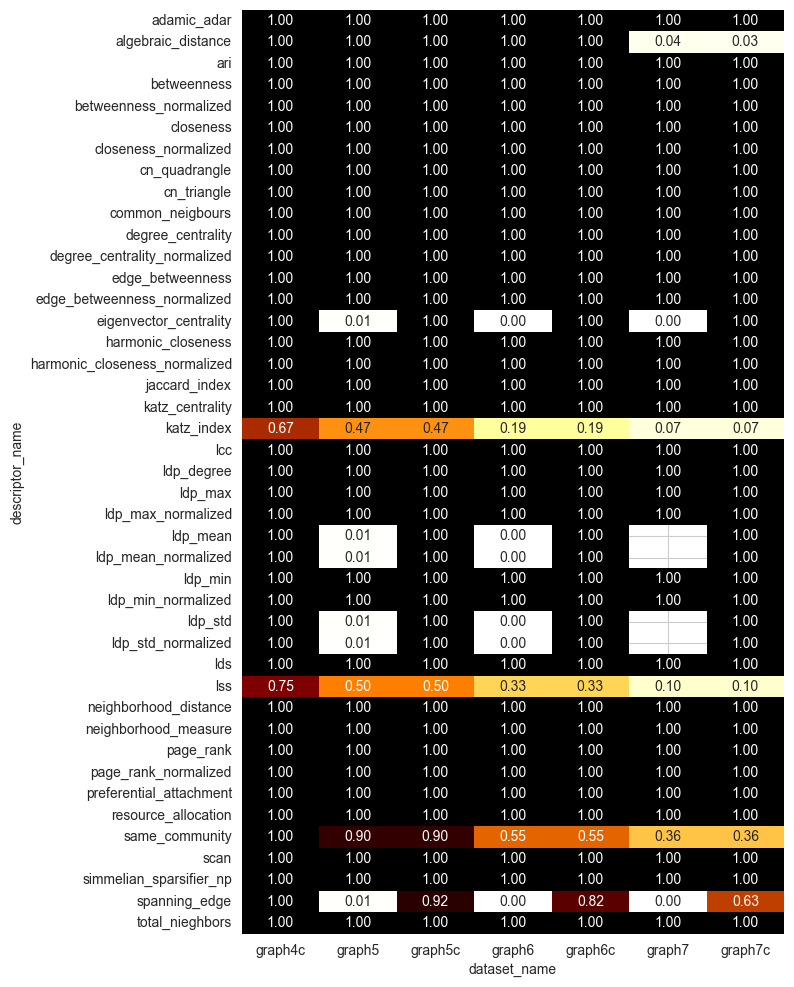

In [72]:
data2d = (
    data [
        ~data['descriptor_name'].str.contains("rounded")
    ]
    .pivot(index="descriptor_name", columns="dataset_name", values="mod_same_vector").sort_index())

show_2d_data(data2d)

In [73]:
print(
    generate_latex_table(
        data2d.transpose(), 
        caption="PI score for descriptors for graphs with fixed number of nodes ranges from 4 to 7",
        label='PIscore1'
    )
)  



\begin{center}
\setlength{\tabcolsep}{1.5pt}
\renewcommand{\arraystretch}{1.3}
\tiny

\begin{tabular}{ |l|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c| } 
\hline
\\ & \multicolumn{43}{|c|}{Descriptor} \\
\hline
Dataset & \begin{sideways} adamic\_adar \end{sideways} & \begin{sideways} algebraic\_distance \end{sideways} & \begin{sideways} ari \end{sideways} & \begin{sideways} betweenness \end{sideways} & \begin{sideways} betweenness\_normalized \end{sideways} & \begin{sideways} closeness \end{sideways} & \begin{sideways} closeness\_normalized \end{sideways} & \begin{sideways} cn\_quadrangle \end{sideways} & \begin{sideways} cn\_triangle \end{sideways} & \begin{sideways} common\_neigbours \end{sideways} & \begin{sideways} degree\_centrality \end{sideways} & \begin{sideways} degree\_centrality\_normalized \end{sideways} & \begin{sideways} edge\_betweenness \end{sideways} & \begin{sideways} edge\_betweenness\_normalized \end{sideways} & \begin{sidew

## Fixed descriptor

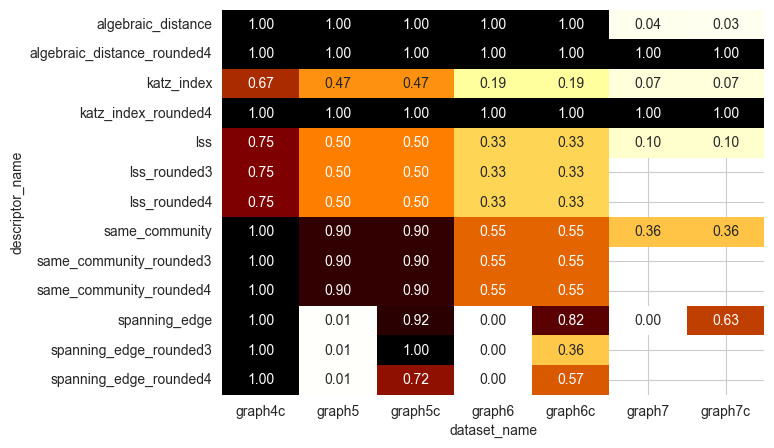

In [77]:
data2d = (
    data [
        (data['descriptor_name'].str.contains("algebraic") & ~data['descriptor_name'].str.contains("rounded3"))
        | data['descriptor_name'].str.contains("katz_index")
        | data['descriptor_name'].str.contains("lss")
        | data['descriptor_name'].str.contains("same_community")
        | data['descriptor_name'].str.contains("spanning_edge")

    ]
    .pivot(index="descriptor_name", columns="dataset_name", values="mod_same_vector").sort_index())

show_2d_data(data2d, size=(7, 5))

In [78]:
print(
    generate_latex_table(
        data2d.transpose(), 
        caption="PI score for rounded descriptors. As shown, Algebraic Distance and Katz Index started working properly after rounding to 4th decimal place.",
        label='PIscore2'
    )
)  


\begin{center}
\setlength{\tabcolsep}{1.5pt}
\renewcommand{\arraystretch}{1.3}
\tiny

\begin{tabular}{ |l|c|c|c|c|c|c|c|c|c|c|c|c|c| } 
\hline
\\ & \multicolumn{13}{|c|}{Descriptor} \\
\hline
Dataset & \begin{sideways} algebraic\_distance \end{sideways} & \begin{sideways} algebraic\_distance\_rounded4 \end{sideways} & \begin{sideways} katz\_index \end{sideways} & \begin{sideways} katz\_index\_rounded4 \end{sideways} & \begin{sideways} lss \end{sideways} & \begin{sideways} lss\_rounded3 \end{sideways} & \begin{sideways} lss\_rounded4 \end{sideways} & \begin{sideways} same\_community \end{sideways} & \begin{sideways} same\_community\_rounded3 \end{sideways} & \begin{sideways} same\_community\_rounded4 \end{sideways} & \begin{sideways} spanning\_edge \end{sideways} & \begin{sideways} spanning\_edge\_rounded3 \end{sideways} & \begin{sideways} spanning\_edge\_rounded4 \end{sideways} \\
\hline
graph4c & 1. & 1. & \cellcolor[HTML]{FF9898}.67 & 1. & \cellcolor[HTML]{FF9898}.75 & \cellcolor[HT

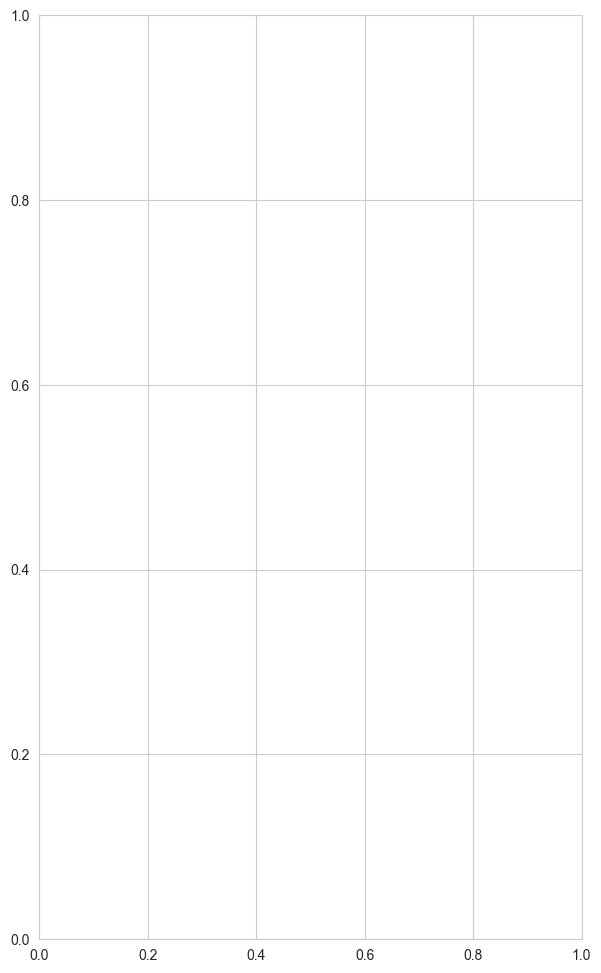

In [ ]:
data2d_time = data.pivot(index="descriptor_name", columns="dataset_name", values="time").sort_index()

fig, ax1 = plt.subplots(
    1, 1,
    figsize=(7, 12),
)
# sns.heatmap(
#     data2d_time,
#     cmap='afmhot',
#     annot=np.round(data2d_time, 6),
#     fmt=".6f",
#     cbar=False,
#     ax=ax1,
# )
